In [1]:
import random
import scienceplots
import os
from collections import Counter
import functools
from importlib import reload
import pickle
import copy
import re
import warnings
import utils
reload(utils)
import utils_selection
reload(utils_selection)

import numpy as np
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LassoCV, LassoLarsCV, Lasso
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning


/opt/homebrew/anaconda3/envs/clinfo2/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Ancestry

Parameters for experiments

In [10]:
# data_name = 'ancestry' # Use this filename to produce new results!
data_name = 'ancestry_all_aims_rsID' # Use this to load pre-computed results!

# Lasso-based feature selection and ML evaluation
seeds = [0, 1, 2,3,4]
shots = [10,20,40,80,160,320,640] 

file = 'ancestry_maybe_snps.pkl'
with open('ancestry_maybe_snps.pkl', 'rb') as file:
    maybe_snps = pickle.load(file)

In [12]:
# PCA
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_pca, rf_results_pca, _ = utils_selection.evaluate_feature_selection(data_name, "pca", seeds, shots, return_stored_results=True)
    utils_selection.print_results("pca", "ancestry", log_reg_results_pca, rf_results_pca, shots)

../data/selected_features/feature_selection_ancestry_all_aims_rsID_pca_[10, 20, 40, 80, 160, 320, 640]_[0, 1, 2, 3, 4]_15.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pca feature selection on k-shot classification for: ancestry

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  10  | Logistic Regression |    0.4623    | 0.04 | 0.7304  | 0.02 |    0.3631    | 0.09 |
|  10  |    Random Forest    |    0.3906    | 0.06 | 0.7148  | 0.02 |    0.3025    | 0.10 |
|  20  | Logistic Regression |    0.5099    | 0.04 | 0.7553  | 0.03 |    0.5064    | 0.03 |
|  20  |    Random Forest    |    0.4984    | 0.03 | 0.7517  | 0.04 |    0.4934    | 0.03 |
|  40  | Logistic Regress

In [13]:
# PCA_m
reload(utils_selection)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_pca_m, rf_results_pca_m, _ = utils_selection.evaluate_feature_selection(data_name, "pca_m", seeds, shots, return_stored_results=True)
    utils_selection.print_results("pca", "ancestry", log_reg_results_pca_m, rf_results_pca_m, shots)

../data/selected_features/feature_selection_ancestry_all_aims_rsID_pca_m_[10, 20, 40, 80, 160, 320, 640]_[0, 1, 2, 3, 4]_15.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pca feature selection on k-shot classification for: ancestry

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  10  | Logistic Regression |    0.6906    | 0.04 | 0.8726  | 0.02 |    0.6641    | 0.04 |
|  10  |    Random Forest    |    0.6058    | 0.17 | 0.7997  | 0.15 |    0.5674    | 0.23 |
|  20  | Logistic Regression |    0.7653    | 0.04 | 0.9133  | 0.03 |    0.7463    | 0.05 |
|  20  |    Random Forest    |    0.7452    | 0.07 | 0.9003  | 0.03 |    0.7261    | 0.06 |
|  40  | Logistic Regre

In [14]:
# Lasso
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_lasso, rf_results_lasso,_ = utils_selection.evaluate_feature_selection(data_name, "lasso", seeds, shots, return_stored_results=True)
    utils_selection.print_results("lasso", "ancestry", log_reg_results_lasso, rf_results_lasso, shots)

../data/selected_features/feature_selection_ancestry_all_aims_rsID_lasso_[10, 20, 40, 80, 160, 320, 640]_[0, 1, 2, 3, 4]_15.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot lasso feature selection on k-shot classification for: ancestry

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  10  | Logistic Regression |    0.5040    | 0.05 | 0.7778  | 0.03 |    0.4961    | 0.06 |
|  10  |    Random Forest    |    0.4430    | 0.03 | 0.7339  | 0.03 |    0.4344    | 0.04 |
|  20  | Logistic Regression |    0.5452    | 0.03 | 0.8135  | 0.01 |    0.5446    | 0.02 |
|  20  |    Random Forest    |    0.5198    | 0.03 | 0.8058  | 0.01 |    0.5086    | 0.01 |
|  40  | Logistic Reg

In [15]:
# Weighted Sum PCA
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_pca_weighted_sum, rf_results_pca_weighted_sum,_ = utils_selection.evaluate_feature_selection(data_name, "pca_weighted_sum", seeds, shots, return_stored_results=True)
    utils_selection.print_results("pca_weighted_sum", "ancestry", log_reg_results_pca_weighted_sum, rf_results_pca_weighted_sum, shots)

../data/selected_features/feature_selection_ancestry_all_aims_rsID_pca_weighted_sum_[10, 20, 40, 80, 160, 320, 640]_[0, 1, 2, 3, 4]_15.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pca_weighted_sum feature selection on k-shot classification for: ancestry

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  10  | Logistic Regression |    0.3141    | 0.07 | 0.6384  | 0.06 |    0.3133    | 0.08 |
|  10  |    Random Forest    |    0.2887    | 0.05 | 0.6201  | 0.03 |    0.2831    | 0.06 |
|  20  | Logistic Regression |    0.4569    | 0.05 | 0.7542  | 0.02 |    0.4653    | 0.04 |
|  20  |    Random Forest    |    0.4284    | 0.07 | 0.7257  | 0.02 |    0.4229    | 0.06 |

In [16]:
# gini
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_gini, rf_results_gini,_ = utils_selection.evaluate_feature_selection(data_name, "gini",  seeds, shots, return_stored_results=True, model="rf",)
    utils_selection.print_results("gini", "ancestry", log_reg_results_gini, rf_results_gini, shots)

../data/selected_features/feature_selection_ancestry_all_aims_rsID_gini_[10, 20, 40, 80, 160, 320, 640]_[0, 1, 2, 3, 4]_15_rf.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot gini feature selection on k-shot classification for: ancestry

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  10  | Logistic Regression |    0.4995    | 0.07 | 0.7802  | 0.05 |    0.5076    | 0.06 |
|  10  |    Random Forest    |    0.4482    | 0.07 | 0.7365  | 0.06 |    0.4542    | 0.06 |
|  20  | Logistic Regression |    0.6636    | 0.05 | 0.8683  | 0.03 |    0.6542    | 0.05 |
|  20  |    Random Forest    |    0.6182    | 0.04 | 0.8477  | 0.02 |    0.6140    | 0.04 |
|  40  | Logistic Re

In [17]:
# backwards
shots = [10,20,40,80,160,320]
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_backward, rf_results_backward,_ = utils_selection.evaluate_feature_selection(data_name, "data_pipeline_backward",  seeds, shots, return_stored_results=True, model="rf",)
    utils_selection.print_results("backward", "ancestry", log_reg_results_backward, rf_results_backward, shots)

../data/selected_features/feature_selection_ancestry_all_aims_rsID_data_pipeline_backward_[10, 20, 40, 80, 160, 320]_[0, 1, 2, 3, 4]_15_rf.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot backward feature selection on k-shot classification for: ancestry

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  10  | Logistic Regression |    0.5681    | 0.10 | 0.8053  | 0.06 |    0.5609    | 0.10 |
|  10  |    Random Forest    |    0.5168    | 0.09 | 0.7693  | 0.06 |    0.5058    | 0.09 |
|  20  | Logistic Regression |    0.6280    | 0.04 | 0.8494  | 0.01 |    0.6262    | 0.03 |
|  20  |    Random Forest    |    0.5642    | 0.04 | 0.8134  | 0.01 |    0.5707    | 0.03 |
|  

In [18]:
# forward
shots = [10,20,40,80,160,320]
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_forward, rf_results_forward, a= utils_selection.evaluate_feature_selection(data_name, "data_pipeline_forward",  seeds, shots, return_stored_results=True, model="rf",)
    utils_selection.print_results("forward", "ancestry", log_reg_results_forward, rf_results_forward, shots)

../data/selected_features/feature_selection_ancestry_all_aims_rsID_data_pipeline_forward_[10, 20, 40, 80, 160, 320]_[0, 1, 2, 3, 4]_15_rf.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot forward feature selection on k-shot classification for: ancestry

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  10  | Logistic Regression |    0.5569    | 0.04 | 0.8089  | 0.02 |    0.5500    | 0.03 |
|  10  |    Random Forest    |    0.4869    | 0.05 | 0.7712  | 0.03 |    0.4735    | 0.04 |
|  20  | Logistic Regression |    0.6602    | 0.04 | 0.8681  | 0.02 |    0.6543    | 0.04 |
|  20  |    Random Forest    |    0.6222    | 0.04 | 0.8448  | 0.02 |    0.6235    | 0.04 |
|  40

In [21]:
# Pyramid
reload(utils)
reload(utils_selection)
shots = [10,20,40,80,160,320,640]
log_reg_results_pyramid, rf_results_pyramid, a  = utils_selection.evaluate_feature_selection(data_name, "pyramid", seeds, shots, feature_selection_pool=maybe_snps, return_stored_results=True, use_grid_search=False,load_specific_pkl = '_2024-09-13 05:01:02')
utils_selection.print_results("pyramid", "ancestry", log_reg_results_pyramid, rf_results_pyramid, shots)

../data/selected_features/feature_selection_ancestry_all_aims_rsID_pyramid_[10, 20, 40, 80, 160, 320, 640]_[0, 1, 2, 3, 4]_15_2024-09-13 05:01:02.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pyramid feature selection on k-shot classification for: ancestry

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  10  | Logistic Regression |    0.7701    | 0.05 | 0.9281  | 0.02 |    0.7625    | 0.04 |
|  10  |    Random Forest    |    0.7589    | 0.04 | 0.9139  | 0.02 |    0.7473    | 0.03 |
|  20  | Logistic Regression |    0.8283    | 0.03 | 0.9493  | 0.02 |    0.8215    | 0.03 |
|  20  |    Random Forest    |    0.8185    | 0.04 | 0.9454  | 0.02 |    0.8055    | 0.03

In [22]:
# Pyramid
reload(utils)
reload(utils_selection)
log_reg_results_pyramid, rf_results_pyramid, a  = utils_selection.evaluate_feature_selection(data_name, "pyramid", seeds, shots, feature_selection_pool=maybe_snps, return_stored_results=True, use_grid_search=True, load_specific_pkl='2024-09-13 05:34:50')
utils_selection.print_results("pyramid", "ancestry", log_reg_results_pyramid, rf_results_pyramid, shots)

../data/selected_features/feature_selection_ancestry_all_aims_rsID_pyramid_[10, 20, 40, 80, 160, 320, 640]_[0, 1, 2, 3, 4]_152024-09-13 05:34:50.pkl
Found existing file with seeds: [0, 1, 2, 3, 4]. Loading partial results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pyramid feature selection on k-shot classification for: ancestry

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  10  | Logistic Regression |    0.7714    | 0.05 | 0.9204  | 0.03 |    0.7504    | 0.04 |
|  10  |    Random Forest    |    0.7569    | 0.04 | 0.9090  | 0.02 |    0.7414    | 0.04 |
|  20  | Logistic Regression |    0.8222    | 0.03 | 0.9427  | 0.01 |    0.8134    | 0.02 |
|  20  |    Random Forest    |    0.82

In [36]:
# with open('../data/selected_features/feature_selection_ancestry_all_aims_rsID_pyramid_[10, 20, 40, 80, 160, 320, 640]_[0, 1, 2, 3]_15.pkl', 'rb') as file:
#     temp_data = pickle.load(file)
# temp_data['feature_selections'][4] = ['rs12913832', 'rs4988235', 'rs671', 'rs2814778', 'rs1426654', 'rs16891982', 'rs3827760', 'rs2047001', 'rs10492947', 'rs174570', 'rs4420638', 'rs1407514', 'rs10493096', 'rs2046071', 'rs3910044']
# # Save the `data` back into a .pkl file
# with open('../data/selected_features/feature_selection_ancestry_all_aims_rsID_pyramid_[10, 20, 40, 80, 160, 320, 640]_[0, 1, 2, 3,4]_15.pkl', 'wb') as file:
#     pickle.dump(temp_data, file)

In [23]:
# Iterative
reload(utils_selection)
log_reg_results_iterative, rf_results_iterative, b = utils_selection.evaluate_feature_selection(data_name, "iterative_self_consistency", seeds, shots, feature_selection_pool=maybe_snps, return_stored_results=True)
utils_selection.print_results("pyramid", "iterative_self_consistency", log_reg_results_iterative, rf_results_iterative, shots)

../data/selected_features/feature_selection_ancestry_all_aims_rsID_iterative_self_consistency_[10, 20, 40, 80, 160, 320, 640]_[0, 1, 2, 3, 4]_15.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pyramid feature selection on k-shot classification for: iterative_self_consistency

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  10  | Logistic Regression |    0.7565    | 0.05 | 0.9147  | 0.02 |    0.7491    | 0.04 |
|  10  |    Random Forest    |    0.7136    | 0.04 | 0.8966  | 0.02 |    0.7030    | 0.04 |
|  20  | Logistic Regression |    0.8014    | 0.04 | 0.9331  | 0.02 |    0.7880    | 0.04 |
|  20  |    Random Forest    |    0.7947    | 0.04 | 0.9315  | 0.01 |   

In [24]:
# LLM-select
log_reg_results_llm_select, rf_results_llm_select, a  = utils_selection.evaluate_feature_selection(data_name, "llm_select", seeds, shots, feature_selection_pool=maybe_snps, return_stored_results=True)
utils_selection.print_results("pyramid", "ancestry", log_reg_results_llm_select, rf_results_llm_select, shots)

../data/selected_features/feature_selection_ancestry_all_aims_rsID_llm_select_[10, 20, 40, 80, 160, 320, 640]_[0, 1, 2, 3, 4]_15.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pyramid feature selection on k-shot classification for: ancestry

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  10  | Logistic Regression |    0.7511    | 0.06 | 0.9008  | 0.03 |    0.7379    | 0.05 |
|  10  |    Random Forest    |    0.7304    | 0.06 | 0.8869  | 0.01 |    0.7132    | 0.05 |
|  20  | Logistic Regression |    0.7891    | 0.03 | 0.9255  | 0.02 |    0.7820    | 0.03 |
|  20  |    Random Forest    |    0.7973    | 0.04 | 0.9341  | 0.02 |    0.7866    | 0.04 |
|  40  | Logis

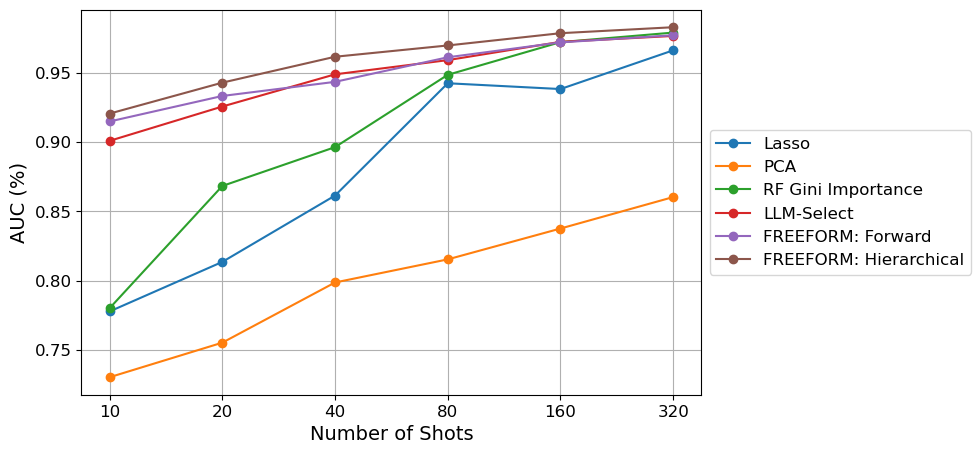

In [ ]:
# Assuming you have results from multiple methods
# Assuming you have already computed the results for each method
results_dict = {
    'Lasso': log_reg_results_lasso,
    'PCA': log_reg_results_pca,
    'RF Gini Importance': log_reg_results_gini,
    #'Forward': log_reg_results_forward,
    'LLM-Select': log_reg_results_llm_select,
    'FREEFORM: Forward': log_reg_results_iterative,
    'FREEFORM: Hierarchical':  log_reg_results_pyramid,
}
shots = [10,20,40,80,160, 320] 

utils_selection.plot_results("Ancestry", "lr", results_dict, shots)

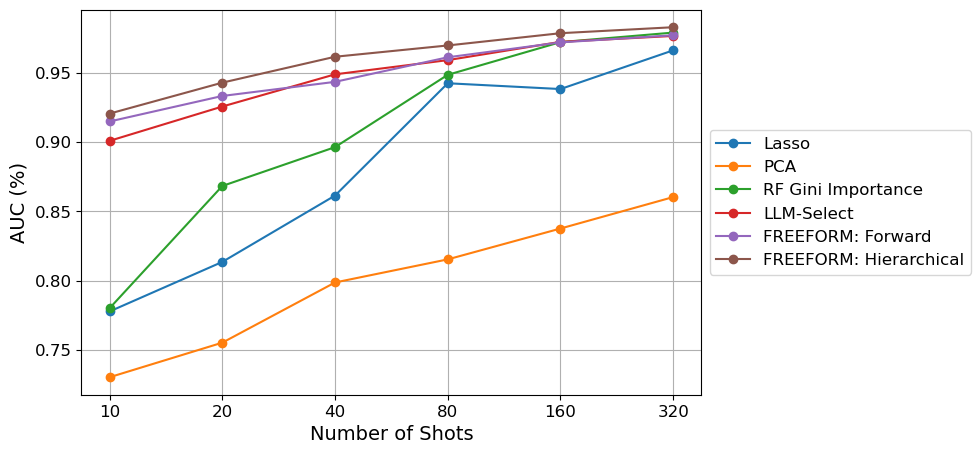

In [28]:
# Assuming you have results from multiple methods
# Assuming you have already computed the results for each method
results_dict_rf = {
    'Lasso': rf_results_lasso,
    'PCA': rf_results_pca,
    'RF Gini Importance': rf_results_gini,
    #'Forward': rf_results_forward,
    'LLM-Select': rf_results_llm_select,
    'FREEFORM: Forward': rf_results_iterative,
    'FREEFORM: Hierarchical':  rf_results_pyramid,
}
shots = [10,20,40,80,160, 320] 

utils_selection.plot_results("Ancestry", "rf", results_dict, shots)

## Hearing Loss

In [29]:
data_name = 'hearing_loss_modified'


# Lasso-based feature selection and ML evaluation
seeds = [0, 1, 2,3,4]
shots = [4,8,16,32,64,128,256] 

file = 'hearing_loss_maybe_snps.pkl'
with open(file, 'rb') as file:
    maybe_snps = pickle.load(file)

In [31]:
# PCA
reload(utils_selection)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_pca_hearing_loss, rf_results_pca_hearing_loss, _ = utils_selection.evaluate_feature_selection(data_name, "pca", seeds, shots, return_stored_results=True)
    utils_selection.print_results("pca", "hearing_loss", log_reg_results_pca_hearing_loss, rf_results_pca_hearing_loss, shots)

../data/selected_features/feature_selection_hearing_loss_modified_pca_[4, 8, 16, 32, 64, 128, 256]_[0, 1, 2, 3, 4]_15.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pca feature selection on k-shot classification for: hearing_loss

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  4   | Logistic Regression |    0.4344    | 0.10 | 0.5001  | 0.04 |    0.4371    | 0.13 |
|  4   |    Random Forest    |    0.4391    | 0.17 | 0.4843  | 0.03 |    0.3919    | 0.23 |
|  8   | Logistic Regression |    0.4374    | 0.05 | 0.4768  | 0.04 |    0.4659    | 0.06 |
|  8   |    Random Forest    |    0.3609    | 0.08 | 0.4752  | 0.05 |    0.3392    | 0.14 |
|  16  | Logistic Regress

In [33]:
# Lasso
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_lasso_hearing_loss, rf_results_lasso_hearing_loss, _ = utils_selection.evaluate_feature_selection(data_name, "lasso", seeds, shots, return_stored_results=True)
    utils_selection.print_results("lasso", "hearing_loss", log_reg_results_lasso_hearing_loss, rf_results_lasso_hearing_loss, shots)

../data/selected_features/feature_selection_hearing_loss_modified_lasso_[4, 8, 16, 32, 64, 128, 256]_[0, 1, 2, 3, 4]_15.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot lasso feature selection on k-shot classification for: hearing_loss

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  4   | Logistic Regression |    0.5242    | 0.21 | 0.4797  | 0.04 |    0.4704    | 0.19 |
|  4   |    Random Forest    |    0.3652    | 0.17 | 0.4838  | 0.04 |    0.3000    | 0.19 |
|  8   | Logistic Regression |    0.4424    | 0.14 | 0.4868  | 0.04 |    0.4260    | 0.19 |
|  8   |    Random Forest    |    0.4083    | 0.16 | 0.5017  | 0.06 |    0.3659    | 0.21 |
|  16  | Logistic Reg

In [34]:
# Weighted Sum PCA

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_pca_weighted_sum_hearing_loss, rf_results_pca_weighted_sum_hearing_loss, _ = utils_selection.evaluate_feature_selection(data_name, "pca_weighted_sum", seeds, shots, return_stored_results=True)
    utils_selection.print_results("pca_weighted_sum", "hearing_loss", log_reg_results_pca_weighted_sum_hearing_loss, rf_results_pca_weighted_sum_hearing_loss, shots)

../data/selected_features/feature_selection_hearing_loss_modified_pca_weighted_sum_[4, 8, 16, 32, 64, 128, 256]_[0, 1, 2, 3, 4]_15.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pca_weighted_sum feature selection on k-shot classification for: hearing_loss

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  4   | Logistic Regression |    0.4530    | 0.11 | 0.4890  | 0.03 |    0.4471    | 0.18 |
|  4   |    Random Forest    |    0.4719    | 0.16 | 0.4806  | 0.04 |    0.4486    | 0.19 |
|  8   | Logistic Regression |    0.4877    | 0.07 | 0.4753  | 0.04 |    0.5095    | 0.07 |
|  8   |    Random Forest    |    0.4096    | 0.16 | 0.4732  | 0.03 |    0.3706    | 0.20 |

In [35]:
# Backwards
reload(utils_selection)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_backward_hearing_loss, rf_results_backward_hearing_loss, _ = utils_selection.evaluate_feature_selection(data_name, "backward_selection", seeds, shots, return_stored_results=True, model = "lr", load_specific_pkl='')
    utils_selection.print_results("backwards selection", "hearing_loss", log_reg_results_backward_hearing_loss, rf_results_backward_hearing_loss, shots)

../data/selected_features/feature_selection_hearing_loss_modified_backward_selection_[4, 8, 16, 32, 64, 128, 256]_[0, 1, 2, 3, 4]_15_lr.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot backwards selection feature selection on k-shot classification for: hearing_loss

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  4   | Logistic Regression |    0.4818    | 0.17 | 0.4923  | 0.01 |    0.4511    | 0.19 |
|  4   |    Random Forest    |    0.4199    | 0.17 | 0.4937  | 0.01 |    0.3640    | 0.23 |
|  8   | Logistic Regression |    0.4500    | 0.07 | 0.5073  | 0.03 |    0.4693    | 0.08 |
|  8   |    Random Forest    |    0.3924    | 0.10 | 0.5110  | 0.06 |    0.3655    

In [36]:
# forward
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_forward_hearing_loss, rf_results_forward_hearing_loss, a1 = utils_selection.evaluate_feature_selection(data_name, "forward_selection", seeds, shots, model = "lr", return_stored_results=True)
    utils_selection.print_results("pca_weighted_sum", "hearing_loss", log_reg_results_forward_hearing_loss, rf_results_forward_hearing_loss, shots)

../data/selected_features/feature_selection_hearing_loss_modified_forward_selection_[4, 8, 16, 32, 64, 128, 256]_[0, 1, 2, 3, 4]_15_lr.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pca_weighted_sum feature selection on k-shot classification for: hearing_loss

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  4   | Logistic Regression |    0.5205    | 0.22 | 0.4987  | 0.01 |    0.4357    | 0.25 |
|  4   |    Random Forest    |    0.5043    | 0.21 | 0.4952  | 0.01 |    0.4311    | 0.24 |
|  8   | Logistic Regression |    0.3907    | 0.06 | 0.5071  | 0.04 |    0.3852    | 0.11 |
|  8   |    Random Forest    |    0.3735    | 0.07 | 0.5090  | 0.05 |    0.3536    | 0.

In [37]:
# data-driven pipeline
reload(utils_selection)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_forward_hearing_loss, rf_results_forward_hearing_loss, _ = utils_selection.evaluate_feature_selection(data_name, "data_pipeline_forward", seeds, shots, return_stored_results=True, model="rf")
    utils_selection.print_results("data driven forward", "hearing_loss", log_reg_results_forward_hearing_loss, rf_results_forward_hearing_loss, shots)

../data/selected_features/feature_selection_hearing_loss_modified_data_pipeline_forward_[4, 8, 16, 32, 64, 128, 256]_[0, 1, 2, 3, 4]_15_rf.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot data driven forward feature selection on k-shot classification for: hearing_loss

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  4   | Logistic Regression |    0.5507    | 0.19 | 0.4936  | 0.01 |    0.4940    | 0.21 |
|  4   |    Random Forest    |    0.3848    | 0.19 | 0.4952  | 0.01 |    0.2942    | 0.25 |
|  8   | Logistic Regression |    0.4517    | 0.07 | 0.4893  | 0.05 |    0.4672    | 0.08 |
|  8   |    Random Forest    |    0.4017    | 0.10 | 0.5078  | 0.06 |    0.3799 

In [38]:
# data-driven pipeline
reload(utils_selection)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_backward_hearing_loss, rf_results_backward_hearing_loss, _ = utils_selection.evaluate_feature_selection(data_name, "data_pipeline_backward", seeds, shots, return_stored_results=True, model="rf")
    utils_selection.print_results("data driven backwards", "hearing_loss", log_reg_results_backward_hearing_loss, rf_results_backward_hearing_loss, shots)

../data/selected_features/feature_selection_hearing_loss_modified_data_pipeline_backward_[4, 8, 16, 32, 64, 128, 256]_[0, 1, 2, 3, 4]_15_rf.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot data driven backwards feature selection on k-shot classification for: hearing_loss

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  4   | Logistic Regression |    0.4344    | 0.10 | 0.5001  | 0.04 |    0.4371    | 0.13 |
|  4   |    Random Forest    |    0.4454    | 0.17 | 0.4855  | 0.04 |    0.4032    | 0.22 |
|  8   | Logistic Regression |    0.4215    | 0.04 | 0.4847  | 0.04 |    0.4390    | 0.06 |
|  8   |    Random Forest    |    0.3950    | 0.08 | 0.5022  | 0.06 |    0.38

In [39]:
# gini
reload(utils_selection)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_gini_rf_hearing_loss, rf_results_gini_rf_hearing_loss, a1 = utils_selection.evaluate_feature_selection(data_name, "gini", seeds, shots, model = "rf", return_stored_results=True)
    utils_selection.print_results("pca_weighted_sum", "hearing_loss", log_reg_results_gini_rf_hearing_loss, rf_results_gini_rf_hearing_loss, shots)

../data/selected_features/feature_selection_hearing_loss_modified_gini_[4, 8, 16, 32, 64, 128, 256]_[0, 1, 2, 3, 4]_15_rf.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pca_weighted_sum feature selection on k-shot classification for: hearing_loss

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  4   | Logistic Regression |    0.4344    | 0.10 | 0.5001  | 0.04 |    0.4371    | 0.13 |
|  4   |    Random Forest    |    0.4507    | 0.18 | 0.4818  | 0.04 |    0.4006    | 0.23 |
|  8   | Logistic Regression |    0.4295    | 0.05 | 0.4710  | 0.04 |    0.4562    | 0.06 |
|  8   |    Random Forest    |    0.4424    | 0.09 | 0.5037  | 0.06 |    0.4443    | 0.13 |
|  16  |

In [40]:
# permutation
reload(utils_selection)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_permutation_rf_hearing_loss, rf_results_permutation_rf_hearing_loss, a1 = utils_selection.evaluate_feature_selection(data_name, "permutation", seeds, shots, model = "rf", return_stored_results=True)
    utils_selection.print_results("pca_weighted_sum", "hearing_loss", log_reg_results_permutation_rf_hearing_loss, rf_results_permutation_rf_hearing_loss, shots)

../data/selected_features/feature_selection_hearing_loss_modified_permutation_[4, 8, 16, 32, 64, 128, 256]_[0, 1, 2, 3, 4]_15_rf.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pca_weighted_sum feature selection on k-shot classification for: hearing_loss

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  4   | Logistic Regression |    0.3844    | 0.15 | 0.4878  | 0.04 |    0.3485    | 0.19 |
|  4   |    Random Forest    |    0.4772    | 0.20 | 0.4922  | 0.05 |    0.4363    | 0.18 |
|  8   | Logistic Regression |    0.4536    | 0.04 | 0.4829  | 0.03 |    0.4825    | 0.05 |
|  8   |    Random Forest    |    0.4977    | 0.09 | 0.5032  | 0.07 |    0.5190    | 0.08 |
|

In [42]:
# Heiarchical SoC
reload(utils_selection)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_pyramid_hearing_loss, rf_results_pyramid_hearing_loss, a = utils_selection.evaluate_feature_selection("hearing_loss", "pyramid", seeds, shots, feature_selection_pool=maybe_snps,old_pkl_nomenclature=True,return_stored_results=True)
    utils_selection.print_results("pyramid", "hearing_loss", log_reg_results_pyramid_hearing_loss, rf_results_pyramid_hearing_loss, shots)

../data/selected_features/feature_selection_hearing_loss_pyramid.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot pyramid feature selection on k-shot classification for: hearing_loss

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  4   | Logistic Regression |    0.3679    | 0.13 | 0.4857  | 0.06 |    0.3169    | 0.18 |
|  4   |    Random Forest    |    0.3781    | 0.12 | 0.5014  | 0.06 |    0.3318    | 0.15 |
|  8   | Logistic Regression |    0.3401    | 0.05 | 0.4758  | 0.05 |    0.3183    | 0.08 |
|  8   |    Random Forest    |    0.3646    | 0.10 | 0.5176  | 0.06 |    0.3276    | 0.15 |
|  16  | Logistic Regression |    0.4937    | 0.09 | 0.5086  | 0.09 |    0

In [43]:
# Iterative SoC
reload(utils_selection)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    log_reg_results_iterative_soc_hearing_loss, rf_results_iterative_soc_hearing_loss, a = utils_selection.evaluate_feature_selection(data_name, "iterative_self_consistency", seeds, shots, feature_selection_pool=maybe_snps,return_stored_results=True)
    utils_selection.print_results("iterative_self_consistency", "hearing_loss", log_reg_results_iterative_soc_hearing_loss, rf_results_iterative_soc_hearing_loss, shots)

../data/selected_features/feature_selection_hearing_loss_modified_iterative_self_consistency_[4, 8, 16, 32, 64, 128, 256]_[0, 1, 2, 3, 4]_15.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot iterative_self_consistency feature selection on k-shot classification for: hearing_loss

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  4   | Logistic Regression |    0.5526    | 0.22 | 0.4815  | 0.03 |    0.4794    | 0.23 |
|  4   |    Random Forest    |    0.4556    | 0.22 | 0.4832  | 0.03 |    0.3961    | 0.23 |
|  8   | Logistic Regression |    0.3609    | 0.16 | 0.4726  | 0.04 |    0.3161    | 0.19 |
|  8   |    Random Forest    |    0.3543    | 0.16 | 0.4966  | 0.05 |  

In [44]:
# LLM-select
log_reg_results_llm_select_hearing_loss, rf_results_llm_select_hearing_loss, a = utils_selection.evaluate_feature_selection(data_name, "llm_select", seeds, shots, feature_selection_pool=maybe_snps,return_stored_results=True)
utils_selection.print_results("llm_select", "hearing_loss", log_reg_results_llm_select_hearing_loss, rf_results_llm_select_hearing_loss, shots)

../data/selected_features/feature_selection_hearing_loss_modified_llm_select_[4, 8, 16, 32, 64, 128, 256]_[0, 1, 2, 3, 4]_15.pkl
Loading full results...
Results and feature selections have already been calculated and saved.... loading selected features
Results for k-shot llm_select feature selection on k-shot classification for: hearing_loss

+------+---------------------+--------------+------+---------+------+--------------+------+
| SHOT |        Model        | Avg Accuracy | Std  | Avg AUC | Std  | Avg F1 Score | Std  |
+------+---------------------+--------------+------+---------+------+--------------+------+
|  4   | Logistic Regression |    0.4487    | 0.25 | 0.5000  | 0.00 |    0.3185    | 0.27 |
|  4   |    Random Forest    |    0.4457    | 0.24 | 0.4961  | 0.01 |    0.3353    | 0.26 |
|  8   | Logistic Regression |    0.4632    | 0.24 | 0.4945  | 0.01 |    0.3582    | 0.25 |
|  8   |    Random Forest    |    0.3593    | 0.20 | 0.4942  | 0.01 |    0.2464    | 0.21 |
|  16  | Lo

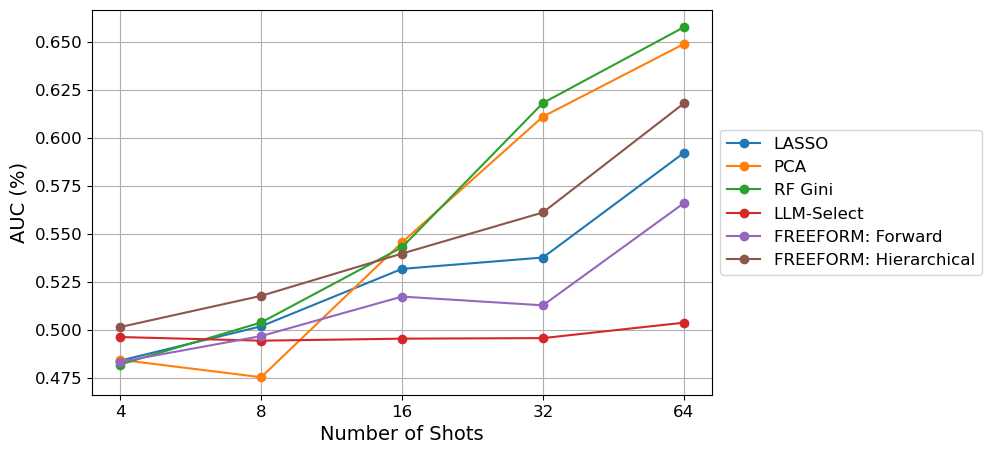

In [50]:
shots = [4,8,16,32,64]
# Assuming you have results from multiple methods
# Assuming you have already computed the results for each method
results_dict_hearing_loss = {
    'LASSO': rf_results_lasso_hearing_loss,
    'PCA': rf_results_pca_hearing_loss,
    "RF Gini": rf_results_gini_rf_hearing_loss,
    # 'Forward': rf_results_forward_hearing_loss,
    # 'Backward': rf_results_backward_hearing_loss,
    'LLM-Select': rf_results_llm_select_hearing_loss,
    'FREEFORM: Forward': rf_results_iterative_soc_hearing_loss,
        'FREEFORM: Hierarchical': rf_results_pyramid_hearing_loss,

    # "permutation": rf_results_permutation_rf_hearing_loss,
}

utils_selection.plot_results("hearing loss", "rf",results_dict_hearing_loss, shots, save=True)

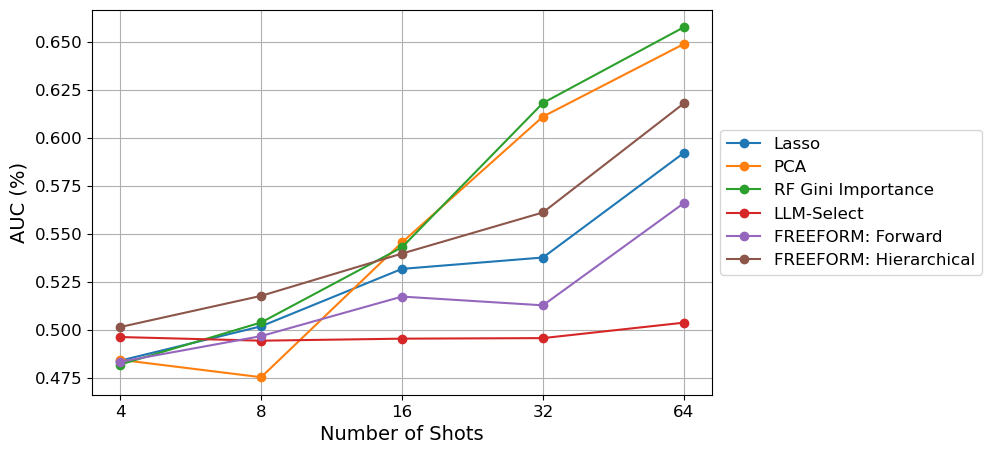

In [46]:
# Assuming you have results from multiple methods
# Assuming you have already computed the results for each method
results_dict_rf_hearing_loss = {
    'Lasso': rf_results_lasso_hearing_loss,
    'PCA': rf_results_pca_hearing_loss,
    "RF Gini Importance": rf_results_gini_rf_hearing_loss,
    #'Forward': rf_results_forward_hearing_loss,
    #'Backward': rf_results_backward_hearing_loss,
    'LLM-Select': rf_results_llm_select_hearing_loss,
    'FREEFORM: Forward': rf_results_iterative_soc_hearing_loss,
    'FREEFORM: Hierarchical': rf_results_pyramid_hearing_loss,
}


utils_selection.plot_results("hearing loss", "rf",results_dict_rf_hearing_loss, shots)

## Analysis

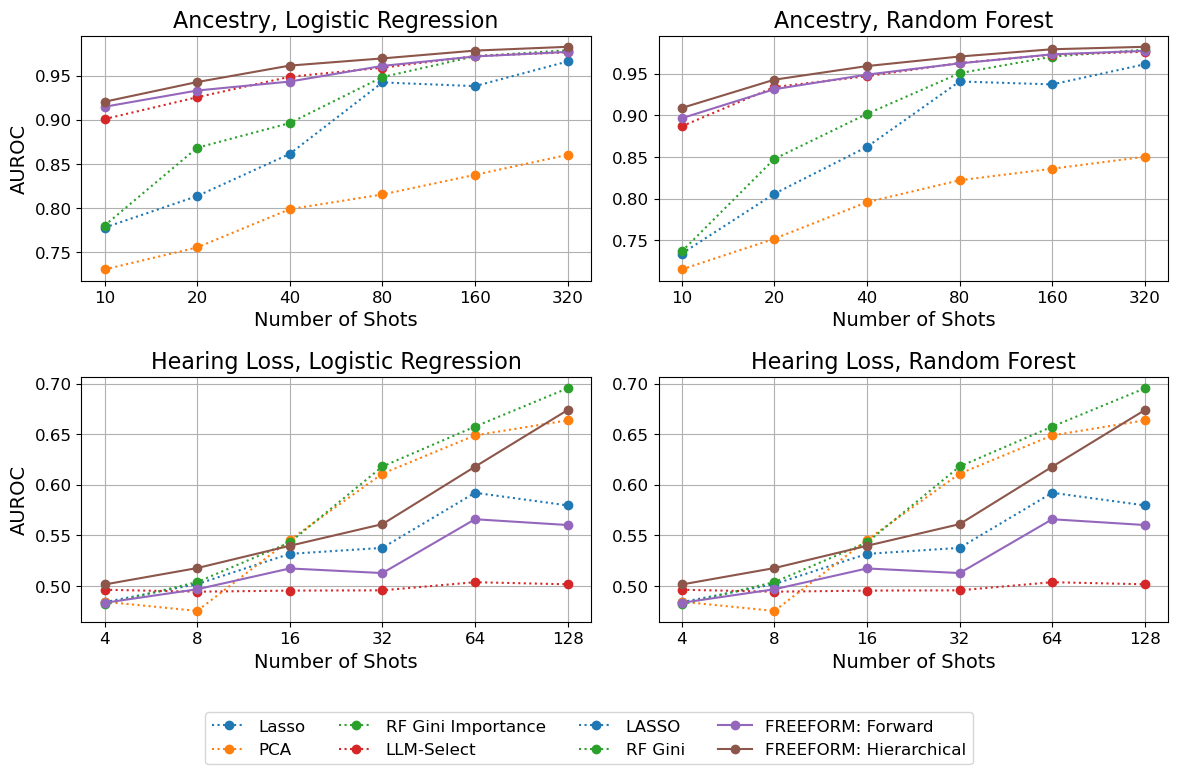

In [51]:
reload(utils_selection)
h_shots = [4,8,16,32,64,128] 
a_shots = [10,20,40,80,160,320] 
shotss = [a_shots,a_shots,h_shots,h_shots]
utils_selection.plot_results_multiple("Ancestry_hearing_loss","rf_lr",
                                      [results_dict, 
                                       results_dict_rf,
                                       results_dict_hearing_loss,
                                       results_dict_rf_hearing_loss], 
                                      shotss,
                                      titles_list=["Ancestry, Logistic Regression", "Ancestry, Random Forest","Hearing Loss, Logistic Regression", "Hearing Loss, Random Forest"], save=True)